In [1]:
%pip install -r ../../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Logistic Regression Training Notebook

This notebook trains a Logistic Regression model on the preprocessed CICEVSE2024 dataset for Multiclass classification. It includes data loading, comprehensive data visualisation, Out-of-Core training (SGDClassifier), evaluation, and model export.

**Dataset**: CICEVSE2024 Network Traffic (14 attack classes + benign)  
**Algorithm**: SGDClassifier with `loss='log_loss'` (equivalent to Logistic Regression)  
**Task**: Multiclass classification of EV charging network intrusions  
**Training Strategy**: Out-of-Core (chunked `partial_fit`) to handle the 2.4 GB dataset

In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tqdm.notebook import tqdm

# --- Configuration ---
USE_BALANCED_DATASET = True

# Plotting config
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="deep")

## 1. Load Data
Load the preprocessed train, validation, and test datasets.

In [4]:
# Adjust path assuming the notebook runs from the project root or src/models/log_reg
if os.path.exists('../../../data/processed'):
    DATA_DIR = '../../../data/processed'
elif os.path.exists('data/processed'):
    DATA_DIR = 'data/processed'
else:
    DATA_DIR = '../data/processed'
print(f"Using data directory: {DATA_DIR}")
# Load targets fully (small enough to fit in RAM)
y_train_file = "y_train_balanced.csv" if USE_BALANCED_DATASET else "y_train.csv"
y_train = pd.read_csv(os.path.join(DATA_DIR, y_train_file))
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))
# Load a small sample of X_train for visualisation (full dataset is 2.4 GB)
X_train_file = "X_train_balanced.csv" if USE_BALANCED_DATASET else "X_train.csv"
X_train_sample = pd.read_csv(os.path.join(DATA_DIR, X_train_file), nrows=50000)
X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))
y_train_multi = y_train["Label_Multiclass"].values.ravel()
y_val_multi = y_val["Label_Multiclass"].values.ravel()
y_test_multi = y_test["Label_Multiclass"].values.ravel()
print("Data loaded successfully!")
print(f"y_train shape: {y_train.shape}")
print(f"X_train_sample shape (for visualisation): {X_train_sample.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Using data directory: ../../../data/processed


Data loaded successfully!
y_train shape: (1125000, 2)
X_train_sample shape (for visualisation): (50000, 67)
X_val shape: (411700, 67)
X_test shape: (411701, 67)


## 1.1 Dataset Overview
Quick inspection of the training data: shape, data types, summary statistics, and missing value check.

In [5]:
total_train = len(y_train)
print(f"Full X_train rows : {total_train:,}")
print(f"X_val rows        : {len(X_val):,}")
print(f"X_test rows       : {len(X_test):,}")
print(f"\nNumber of features: {X_train_sample.shape[1]}")
print(f"\nData types:\n{X_train_sample.dtypes.value_counts()}")
print(f"\nMissing values per column (if any):")
missing = X_train_sample.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("  None — all features are clean.")
else:
    print(missing_cols)

print("\nSummary Statistics (first 10 features):")
X_train_sample.iloc[:, :10].describe().round(3)

Full X_train rows : 1,125,000
X_val rows        : 411,700
X_test rows       : 411,701

Number of features: 67

Data types:
float64    67
Name: count, dtype: int64

Missing values per column (if any):
  None — all features are clean.

Summary Statistics (first 10 features):


,src_port,dst_port,protocol,ip_version,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,-0.313,0.246,4.556,3.301,0.447,0.448,0.605,6.836,7.815,0.447
std,1.251,1.362,21.106,26.228,2.351,2.353,2.898,76.879,85.985,2.351
min,-2.759,-0.487,-3.875,-0.005,-2.244,-2.245,-0.747,-0.009,-0.002,-2.244
25%,-0.702,-0.480,-0.101,-0.005,-0.805,-0.802,-0.747,-0.009,-0.002,-0.805
50%,-0.035,-0.401,-0.101,-0.005,0.577,0.575,-0.747,-0.009,-0.002,0.577
75%,0.603,0.138,-0.101,-0.005,0.625,0.628,1.338,0.010,-0.000,0.625
max,1.426,4.982,181.055,211.376,18.721,18.714,11.903,1259.468,1135.286,18.721


## 1.2 Train / Validation / Test Split Sizes

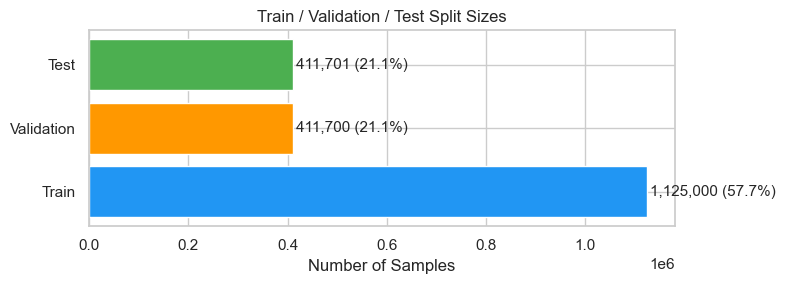

In [6]:
split_sizes = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Samples': [total_train, len(X_val), len(X_test)]
})
split_sizes['Percentage'] = (split_sizes['Samples'] / split_sizes['Samples'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(split_sizes['Split'], split_sizes['Samples'], color=['#2196F3', '#FF9800', '#4CAF50'])
for bar, pct in zip(bars, split_sizes['Percentage']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f} ({pct}%)', va='center', fontsize=11)
ax.set_xlabel('Number of Samples')
ax.set_title('Train / Validation / Test Split Sizes')
plt.tight_layout()
plt.show()

## 1.3 Visualize Class Distributions

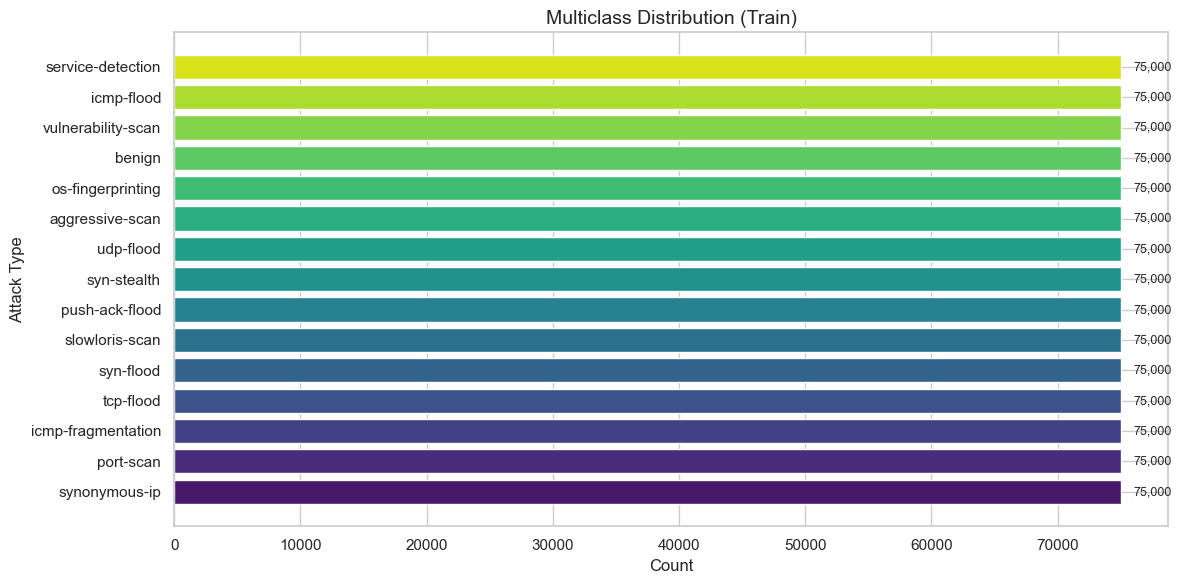


Multiclass label counts:
Label_Multiclass
synonymous-ip         75000
port-scan             75000
icmp-fragmentation    75000
tcp-flood             75000
syn-flood             75000
slowloris-scan        75000
push-ack-flood        75000
syn-stealth           75000
udp-flood             75000
aggressive-scan       75000
os-fingerprinting     75000
benign                75000
vulnerability-scan    75000
icmp-flood            75000
service-detection     75000


In [7]:
multi_counts = y_train['Label_Multiclass'].value_counts()
colors = sns.color_palette('viridis', len(multi_counts))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(multi_counts.index, multi_counts.values, color=colors)
ax.set_title('Multiclass Distribution (Train)', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Attack Type')
for i, val in enumerate(multi_counts.values):
    ax.text(val + 1000, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nMulticlass label counts:")
print(multi_counts.to_string())

## 1.4 Feature Correlation Heatmap

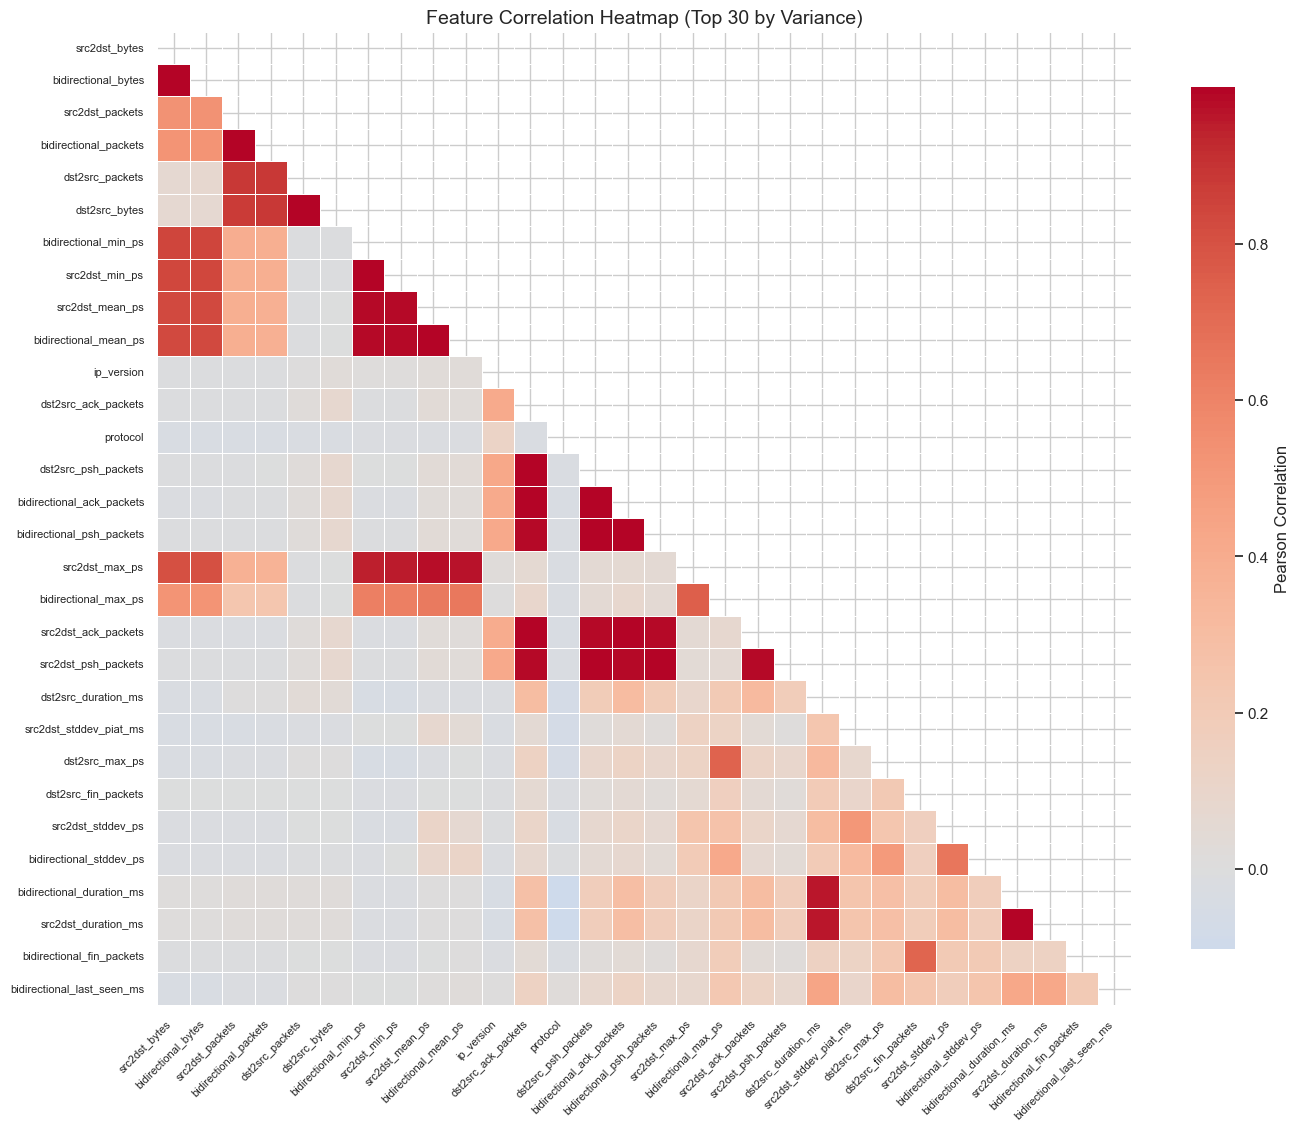

In [8]:
top_features = X_train_sample.var().nlargest(30).index.tolist()
corr_matrix = X_train_sample[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.1f',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
plt.title('Feature Correlation Heatmap (Top 30 by Variance)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 1.5 Feature Distribution Box Plots

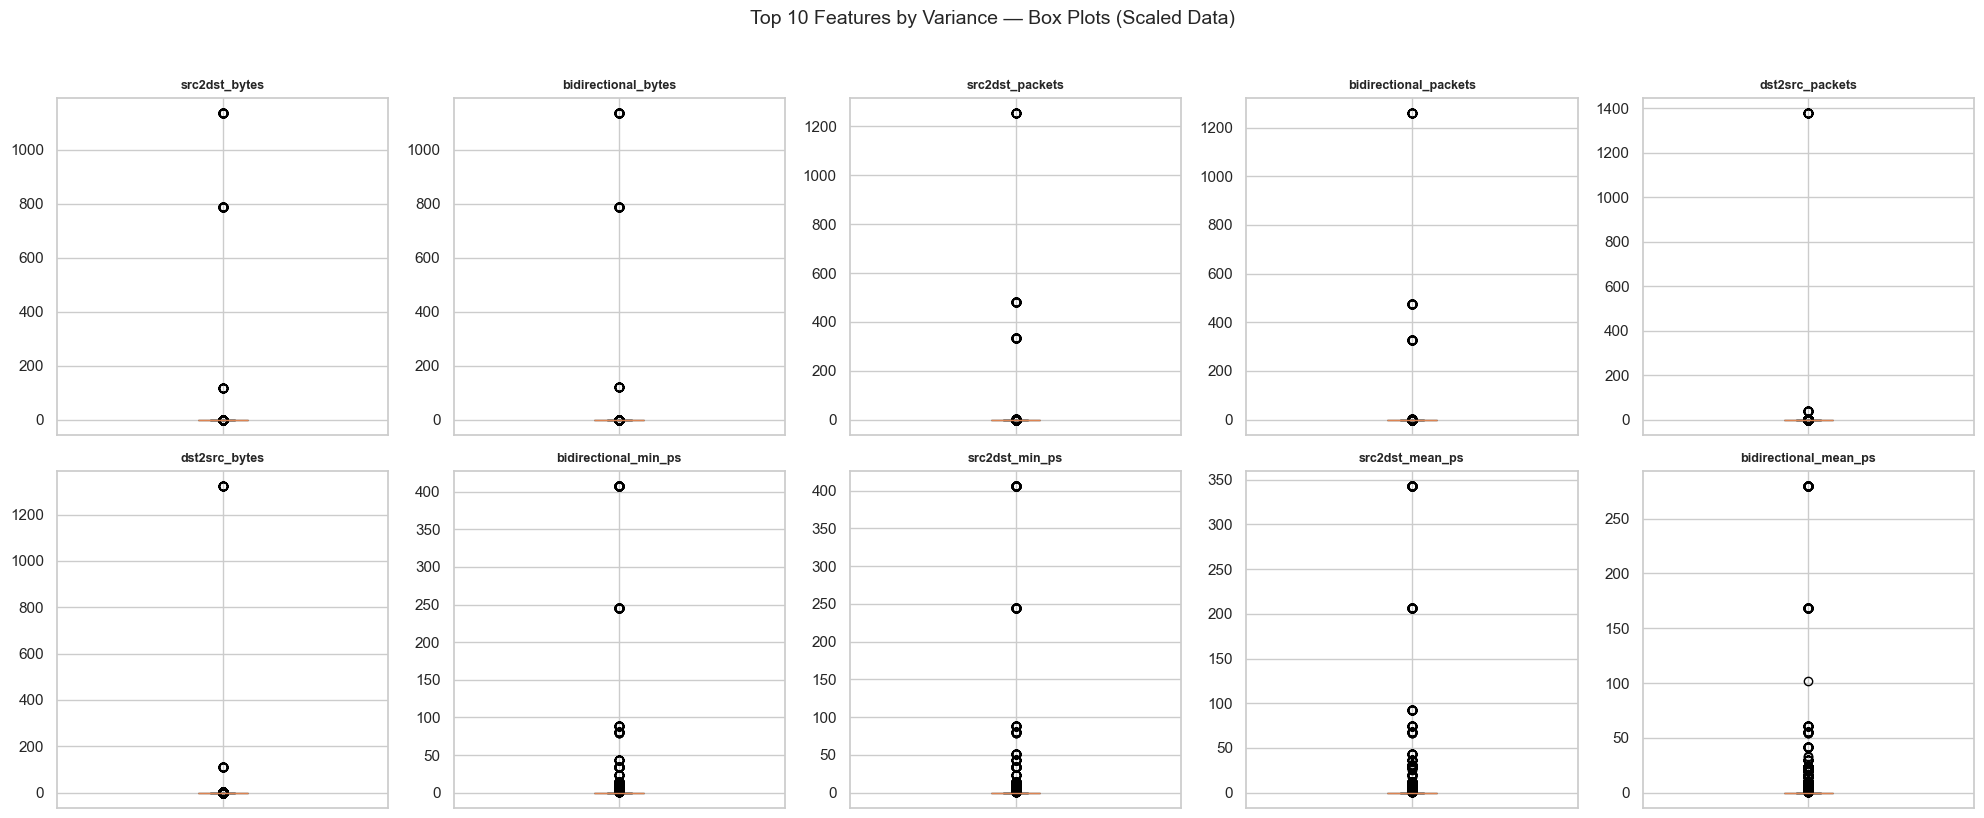

In [9]:
top10 = X_train_sample.var().nlargest(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(top10):
    sample = X_train_sample[col].sample(n=min(10000, len(X_train_sample)), random_state=42)
    axes[i].boxplot(sample.values, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AB47BC', alpha=0.7))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('Top 10 Features by Variance — Box Plots (Scaled Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Train Logistic Regression (Out-of-Core)

We use `SGDClassifier` with `loss='log_loss'` which mathematically replicates Logistic Regression but supports `partial_fit()` for Out-of-Core learning on the 2.4 GB dataset.

We pre-compute class weights for balanced training to handle the extreme class imbalance.

In [10]:
# Pre-compute class weights
classes_multi = np.array(sorted(y_train['Label_Multiclass'].unique()))
weights_m = compute_class_weight('balanced', classes=classes_multi, y=y_train_multi)
class_weight_multi = dict(zip(classes_multi, weights_m))

print(f"Classes ({len(classes_multi)}): {classes_multi}")
print(f"\nClass weights:")
for cls, w in sorted(class_weight_multi.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cls:>25s}: {w:.4f}")

Classes (15): ['aggressive-scan' 'benign' 'icmp-flood' 'icmp-fragmentation'
 'os-fingerprinting' 'port-scan' 'push-ack-flood' 'service-detection'
 'slowloris-scan' 'syn-flood' 'syn-stealth' 'synonymous-ip' 'tcp-flood'
 'udp-flood' 'vulnerability-scan']

Class weights:
            aggressive-scan: 1.0000
                     benign: 1.0000
                 icmp-flood: 1.0000
         icmp-fragmentation: 1.0000
          os-fingerprinting: 1.0000
                  port-scan: 1.0000
             push-ack-flood: 1.0000
          service-detection: 1.0000
             slowloris-scan: 1.0000
                  syn-flood: 1.0000
                syn-stealth: 1.0000
              synonymous-ip: 1.0000
                  tcp-flood: 1.0000
                  udp-flood: 1.0000
         vulnerability-scan: 1.0000


In [11]:
# Initialize model
model_multi = SGDClassifier(loss='log_loss', random_state=42, class_weight=class_weight_multi)
# Training parameters
chunk_size = 100000
total_samples = len(y_train)
print(f"Training Logistic Regression (Out-of-Core) on {total_samples:,} samples...")
print(f"Chunk size: {chunk_size:,}")
X_train_path = os.path.join(DATA_DIR, "X_train_balanced.csv" if USE_BALANCED_DATASET else "X_train.csv")
y_train_path = os.path.join(DATA_DIR, "y_train_balanced.csv" if USE_BALANCED_DATASET else "y_train.csv")
X_chunker = pd.read_csv(X_train_path, chunksize=chunk_size)
y_chunker = pd.read_csv(y_train_path, chunksize=chunk_size)
with tqdm(total=total_samples, desc="Training Logistic Regression") as pbar:
    for X_chunk, y_chunk in zip(X_chunker, y_chunker):
        model_multi.partial_fit(X_chunk, y_chunk["Label_Multiclass"], classes=classes_multi)
        pbar.update(len(X_chunk))
print("\nTraining complete!")


Training Logistic Regression (Out-of-Core) on 1,125,000 samples...
Chunk size: 100,000


Training Logistic Regression:   0%|          | 0/1125000 [00:00<?, ?it/s]


Training complete!


## 3. Evaluation

In [12]:
def evaluate_model(model, X, y, title_prefix=""):
    preds = model.predict(X)
    
    acc = accuracy_score(y, preds)
    f1_macro = f1_score(y, preds, average='macro', zero_division=0)
    f1_weighted = f1_score(y, preds, average='weighted', zero_division=0)
    
    print(f"--- {title_prefix} ---")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro F1-Score : {f1_macro:.4f}")
    print(f"Weighted F1    : {f1_weighted:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y, preds, zero_division=0))
    
    cm = confusion_matrix(y, preds)
    fig_size = max(8, len(np.unique(y)) * 0.8)
    plt.figure(figsize=(fig_size + 2, fig_size))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return preds

--- Logistic Regression — Validation Set ---
Accuracy       : 0.4554
Macro F1-Score : 0.4655
Weighted F1    : 0.4508

Classification Report:


                    precision    recall  f1-score   support

   aggressive-scan       0.04      0.20      0.06     15379
            benign       0.86      1.00      0.92        12
        icmp-flood       0.17      0.80      0.29         5
icmp-fragmentation       0.04      0.75      0.08         4
 os-fingerprinting       0.11      0.10      0.10     21041
         port-scan       0.33      0.16      0.21     63999
    push-ack-flood       1.00      1.00      1.00     29498
 service-detection       0.18      0.01      0.02     43929
    slowloris-scan       0.05      0.97      0.10       630
         syn-flood       1.00      0.99      0.99     39329
       syn-stealth       0.24      0.07      0.11     79641
     synonymous-ip       0.99      1.00      0.99     39328
         tcp-flood       1.00      1.00      1.00     39329
         udp-flood       0.77      1.00      0.87      4871
vulnerability-scan       0.16      0.39      0.22     34705

          accuracy                    

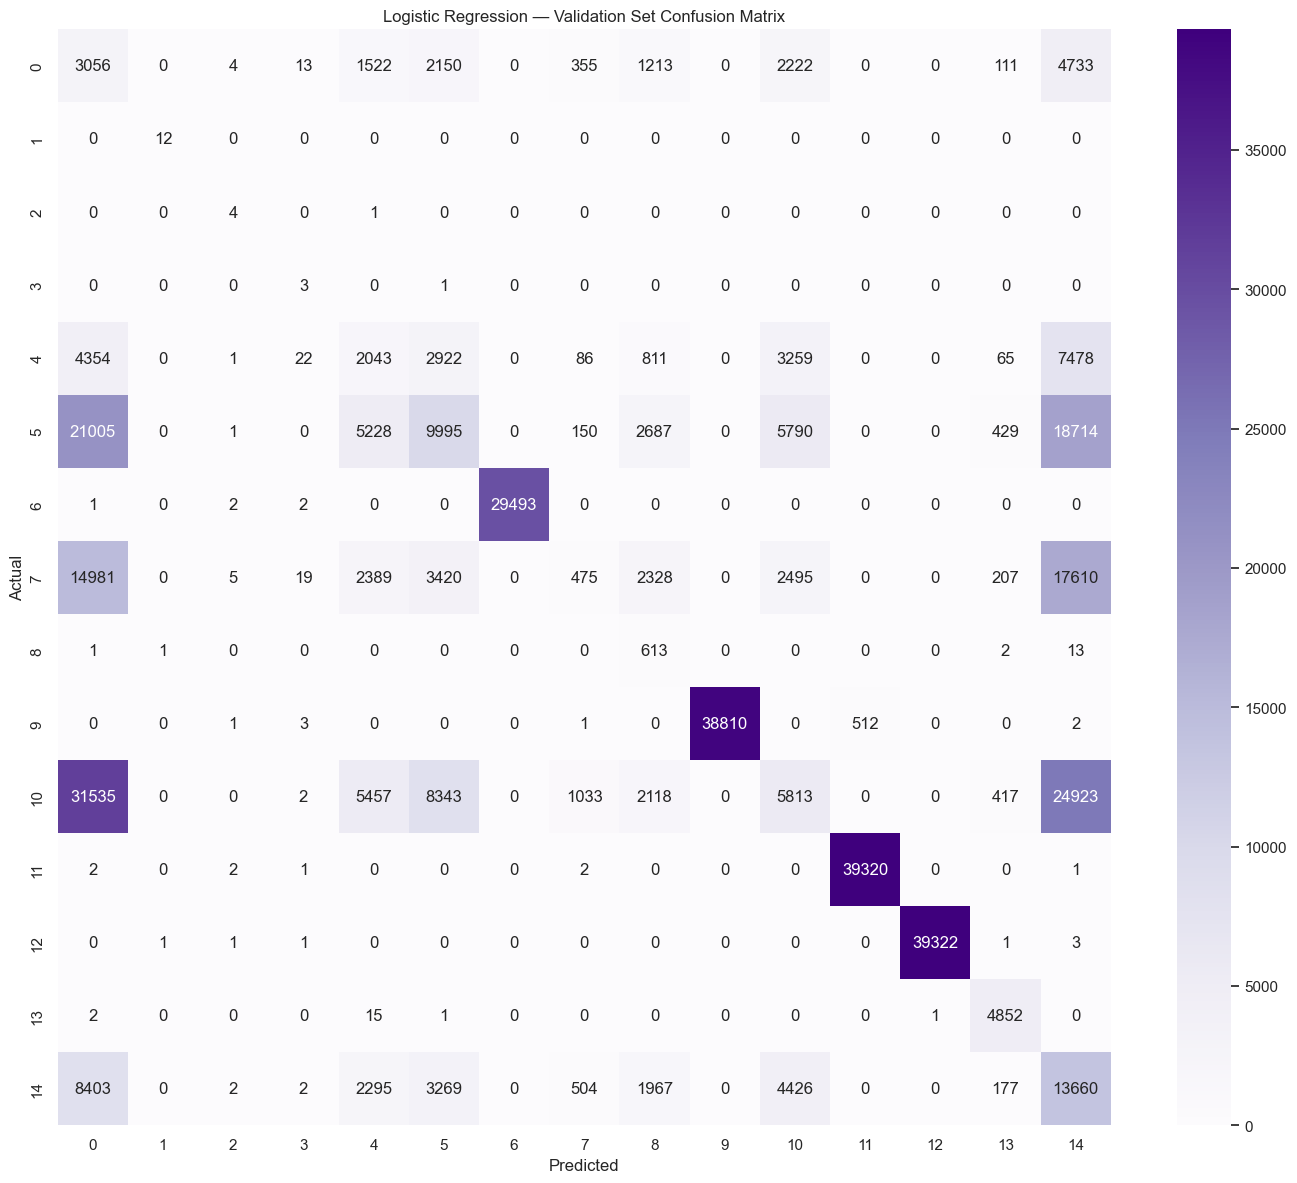

In [13]:
_ = evaluate_model(model_multi, X_val, y_val_multi, title_prefix="Logistic Regression — Validation Set")

--- Logistic Regression — Test Set ---
Accuracy       : 0.4556
Macro F1-Score : 0.4622
Weighted F1    : 0.4509

Classification Report:


                    precision    recall  f1-score   support

   aggressive-scan       0.04      0.20      0.06     15378
            benign       0.75      1.00      0.86        12
        icmp-flood       0.18      0.80      0.30         5
icmp-fragmentation       0.04      0.75      0.08         4
 os-fingerprinting       0.11      0.10      0.10     21041
         port-scan       0.33      0.16      0.21     63999
    push-ack-flood       1.00      1.00      1.00     29498
 service-detection       0.18      0.01      0.02     43928
    slowloris-scan       0.05      0.98      0.10       630
         syn-flood       1.00      0.99      0.99     39330
       syn-stealth       0.24      0.07      0.11     79643
     synonymous-ip       0.99      1.00      0.99     39328
         tcp-flood       1.00      1.00      1.00     39329
         udp-flood       0.77      1.00      0.87      4871
vulnerability-scan       0.16      0.39      0.22     34705

          accuracy                    

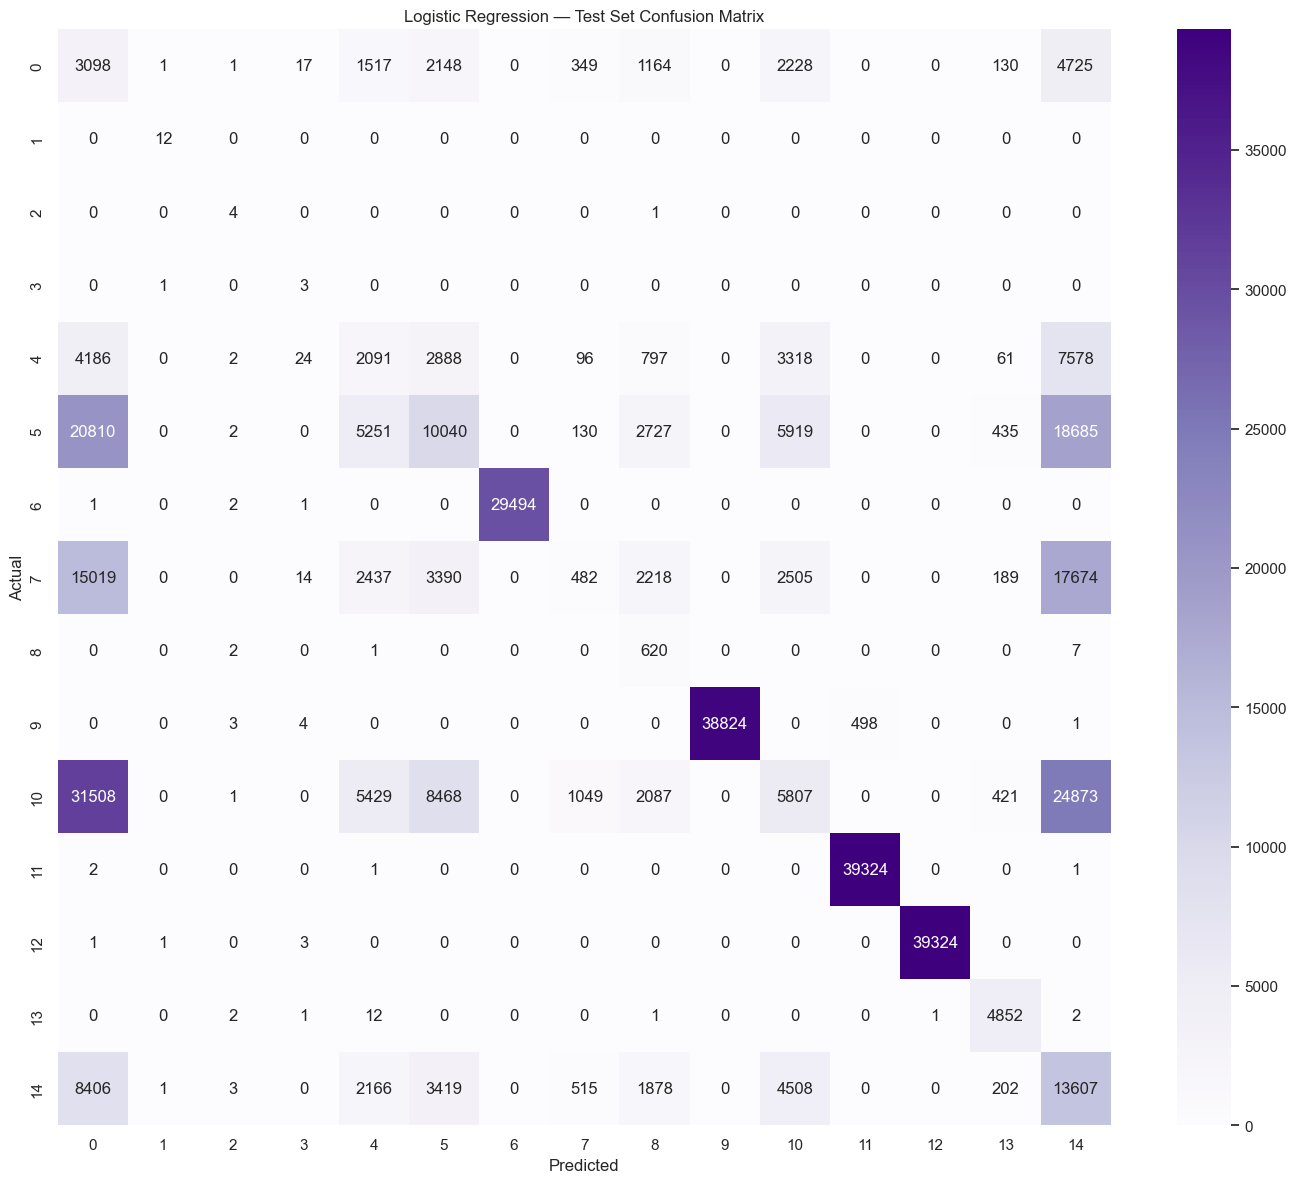

In [14]:
y_pred_test = evaluate_model(model_multi, X_test, y_test_multi, title_prefix="Logistic Regression — Test Set")

## 4. Save Model and Predictions

In [15]:
# Resolve save directories
if os.path.exists('../../../saved_models'):
    SAVE_DIR = '../../../saved_models'
    PREDS_DIR = '../../../predictions'
elif os.path.exists('saved_models'):
    SAVE_DIR = 'saved_models'
    PREDS_DIR = 'predictions'
else:
    SAVE_DIR = '../saved_models'
    PREDS_DIR = '../predictions'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PREDS_DIR, exist_ok=True)

# Save model
model_path = os.path.join(SAVE_DIR, "logreg_model_multiclass.pkl")
joblib.dump(model_multi, model_path)
print(f"Model saved to {model_path}")

# Save predictions
preds_df = pd.DataFrame({
    'Prediction_Multiclass': y_pred_test,
    'y_true': y_test_multi,
    'y_pred': y_pred_test
})
preds_path = os.path.join(PREDS_DIR, "logreg_preds_multiclass.csv")
preds_df.to_csv(preds_path, index=False)
print(f"Predictions saved to {preds_path}")

print("\nLogistic Regression pipeline complete!")

Model saved to ../../../saved_models/logreg_model_multiclass.pkl


Predictions saved to ../../../predictions/logreg_preds_multiclass.csv

Logistic Regression pipeline complete!
